<a href="https://colab.research.google.com/github/harshitnagar22/Celebal_CEI/blob/main/week4_harshit_nagar.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📘 CIFAR-10 Image Classification Learning Project
## Build and Compare **ANN vs CNN** on CIFAR-10

This notebook is designed for **students and beginners** to learn:
- How image classification works
- Why **CNN performs better than ANN**
- How architecture impacts performance
- How training strategies improve results

🎯 **Learning Goal:** Understand the complete DL pipeline by **reading the markdown + running the ready code**.

# 🧠 Problem Statement
Build an image classification model on the **CIFAR-10 dataset** using:

1. **Artificial Neural Network (ANN)**
2. **Convolutional Neural Network (CNN)**

Then compare:
- Accuracy
- Loss curves
- Generalization
- Training strategies (dropout, batch norm, augmentation)

---
### 📦 CIFAR-10 Classes
Airplane, Automobile, Bird, Cat, Deer, Dog, Frog, Horse, Ship, Truck

In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


# 📥 Load Dataset
We use **CIFAR-10**, which contains **60,000 color images of size 32×32×3**.
- 50,000 training images
- 10,000 test images

In [2]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

print("Train shape:", x_train.shape)
print("Test shape:", x_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step
Train shape: (50000, 32, 32, 3)
Test shape: (10000, 32, 32, 3)


## 🖼️ Visualize Sample Images

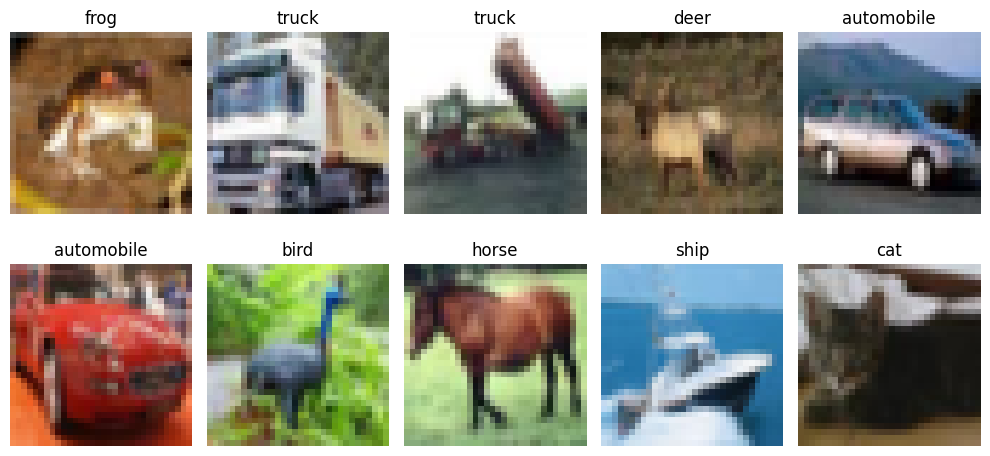

In [3]:
plt.figure(figsize=(10,5))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis("off")
plt.tight_layout()
plt.show()

# 🧹 Preprocessing
We normalize pixel values from **0–255 → 0–1** so training becomes stable.

In [4]:
x_train_norm = x_train / 255.0
x_test_norm = x_test / 255.0

x_train_flat = x_train_norm.reshape(len(x_train_norm), -1)
x_test_flat = x_test_norm.reshape(len(x_test_norm), -1)

# 🔹 Part 1: ANN Model
ANN treats images as **flat vectors**, so it cannot preserve spatial features.
This helps students understand **why CNN is better for images**.

In [5]:
ann_model = models.Sequential([
    layers.Dense(512, activation='relu', input_shape=(3072,)),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.Dense(10, activation='softmax')
])

ann_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

ann_history = ann_model.fit(
    x_train_flat, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 25s 34ms/step - accuracy: 0.2633 - loss: 2.0093 - val_accuracy: 0.3290 - val_loss: 1.8480
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 39s 31ms/step - accuracy: 0.3125 - loss: 1.8770 - val_accuracy: 0.3648 - val_loss: 1.7682
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 43s 34ms/step - accuracy: 0.3336 - loss: 1.8276 - val_accuracy: 0.3774 - val_loss: 1.7452
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 41s 34ms/step - accuracy: 0.3508 - loss: 1.7886 - val_accuracy: 0.3710 - val_loss: 1.7529
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 39s 31ms/step - accuracy: 0.3616 - loss: 1.7577 - val_accuracy: 0.4060 - val_loss: 1.7143
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 22s 31ms/step - accuracy: 0.3654 - loss: 1.7442 - val_accuracy: 0.3954 - val_loss: 1.6976
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 20s 29ms/step - accuracy: 0.3771 - loss: 1.7192 - val_accuracy: 0.4126 - val_loss: 1.6894
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 22s 31ms/step - accuracy: 0.3788 - loss: 1.7024 - 

In [7]:
ann_test_loss, ann_test_acc = ann_model.evaluate(x_test_flat, y_test)
print("ANN Test Accuracy:", ann_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.4209 - loss: 1.6365
ANN Test Accuracy: 0.42089998722076416


# 🔹 Part 2: CNN Model
CNN preserves **spatial relationships** using:
- Convolution layers
- Pooling
- Feature extraction
- Hierarchical learning

This is why CNN performs much better for image tasks.

In [8]:
cnn_model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_history = cnn_model.fit(
    x_train_norm, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 97s 134ms/step - accuracy: 0.4690 - loss: 1.4871 - val_accuracy: 0.5598 - val_loss: 1.2323
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 93s 132ms/step - accuracy: 0.6057 - loss: 1.1253 - val_accuracy: 0.6078 - val_loss: 1.1038
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 146s 139ms/step - accuracy: 0.6698 - loss: 0.9444 - val_accuracy: 0.6176 - val_loss: 1.0923
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 143s 140ms/step - accuracy: 0.7144 - loss: 0.8203 - val_accuracy: 0.6508 - val_loss: 1.0862
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 98s 139ms/step - accuracy: 0.7404 - loss: 0.7414 - val_accuracy: 0.6680 - val_loss: 1.0009
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 95s 135ms/step - accuracy: 0.7709 - loss: 0.6505 - val_accuracy: 0.6598 - val_loss: 1.1010
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 97s 138ms/step - accuracy: 0.7924 - loss: 0.5891 - val_accuracy: 0.7364 - val_loss: 0.8224
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 143s 140ms/step - accuracy: 0.8112 - loss

In [9]:
cnn_test_loss, cnn_test_acc = cnn_model.evaluate(x_test_norm, y_test)
print("CNN Test Accuracy:", cnn_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step - accuracy: 0.7252 - loss: 0.8810
CNN Test Accuracy: 0.7251999974250793


## 📈 Compare Learning Curves

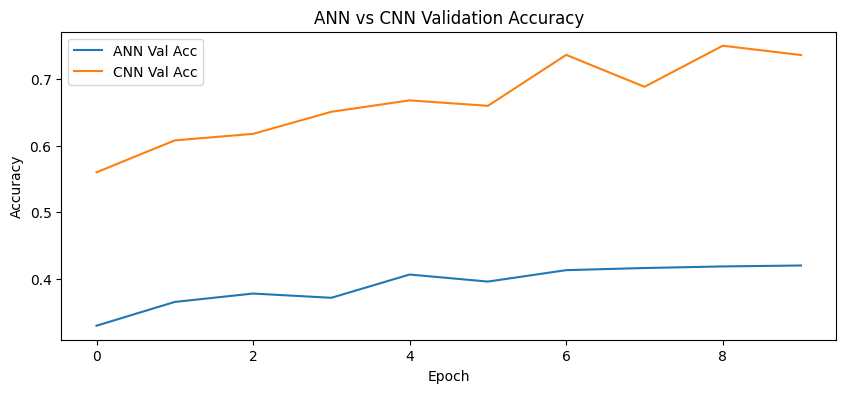

In [10]:
plt.figure(figsize=(10,4))
plt.plot(ann_history.history['val_accuracy'], label='ANN Val Acc')
plt.plot(cnn_history.history['val_accuracy'], label='CNN Val Acc')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("ANN vs CNN Validation Accuracy")
plt.legend()
plt.show()

# 🚀 Training Strategy Upgrade: Data Augmentation
This strategy improves generalization by generating transformed images.

In [11]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])

aug_cnn_model = models.Sequential([
    data_augmentation,
    layers.Conv2D(32, 3, activation='relu', input_shape=(32,32,3)),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, activation='relu'),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

aug_cnn_model.compile(optimizer='adam',
                      loss='sparse_categorical_crossentropy',
                      metrics=['accuracy'])

# Suggested optional run:
# aug_history = aug_cnn_model.fit(x_train_norm, y_train, epochs=10, validation_split=0.1)

# 📊 Final Comparison Table

In [12]:
comparison = pd.DataFrame({
    "Model": ["ANN", "CNN"],
    "Test Accuracy": [ann_test_acc, cnn_test_acc]
})
comparison

,Model,Test Accuracy
0,ANN,0.4209
1,CNN,0.7252


# 🎓 Student Learning Tasks
Try these tasks after understanding the notebook:

### ✅ Beginner Tasks
1. Increase ANN layers and observe performance
2. Change CNN filters from 32→64→128
3. Increase epochs to 20
4. Add **EarlyStopping**
5. Add **data augmentation training**

In [13]:
# Task 1: Increased ANN with more layers
ann_deep = models.Sequential([
    layers.Dense(1024, activation='relu', input_shape=(3072,)),
    layers.Dropout(0.3),
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

ann_deep.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

ann_deep_history = ann_deep.fit(
    x_train_flat, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

ann_deep_loss, ann_deep_acc = ann_deep.evaluate(x_test_flat, y_test)
print("Deep ANN Test Accuracy:", ann_deep_acc)
print("Comparison → Original ANN:", round(ann_test_acc, 4), "| Deep ANN:", round(ann_deep_acc, 4))


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 50s 67ms/step - accuracy: 0.2360 - loss: 2.0510 - val_accuracy: 0.3120 - val_loss: 1.8786
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 83s 69ms/step - accuracy: 0.3062 - loss: 1.8953 - val_accuracy: 0.3416 - val_loss: 1.8536
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 48s 69ms/step - accuracy: 0.3156 - loss: 1.8553 - val_accuracy: 0.3590 - val_loss: 1.8137
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 81s 67ms/step - accuracy: 0.3394 - loss: 1.8180 - val_accuracy: 0.3654 - val_loss: 1.7834
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 47s 67ms/step - accuracy: 0.3440 - loss: 1.7969 - val_accuracy: 0.3646 - val_loss: 1.7615
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 46s 66ms/step - accuracy: 0.3563 - loss: 1.7754 - val_accuracy: 0.3972 - val_loss: 1.7081
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 83s 67ms/step - accuracy: 0.3601 - loss: 1.7599 - val_accuracy: 0.4100 - val_loss: 1.6893
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 46s 65ms/step - accuracy: 0.3691 - loss: 1.7446 - 

In [14]:
# Task 2: CNN with scaled filters 32 -> 64 -> 128 (already done in base CNN, this shows it explicitly)
cnn_scaled = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.Flatten(),

    layers.Dense(256, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

cnn_scaled.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_scaled.summary()

cnn_scaled_history = cnn_scaled.fit(
    x_train_norm, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

cnn_scaled_loss, cnn_scaled_acc = cnn_scaled.evaluate(x_test_norm, y_test)
print("Scaled Filter CNN Test Accuracy:", cnn_scaled_acc)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_5 (Conv2D)               │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 30, 30, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 13, 13, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 4, 4, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 4, 4, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 621,258 (2.37 MB)

 Trainable params: 620,810 (2.37 MB)

 Non-trainable params: 448 (1.75 KB)

Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 99s 134ms/step - accuracy: 0.4850 - loss: 1.5389 - val_accuracy: 0.6080 - val_loss: 1.1014
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 141s 133ms/step - accuracy: 0.6406 - loss: 1.0244 - val_accuracy: 0.5492 - val_loss: 1.3536
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 93s 133ms/step - accuracy: 0.6991 - loss: 0.8529 - val_accuracy: 0.6852 - val_loss: 0.9480
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 142s 133ms/step - accuracy: 0.7416 - loss: 0.7384 - val_accuracy: 0.6262 - val_loss: 1.1381
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 143s 134ms/step - accuracy: 0.7739 - loss: 0.6428 - val_accuracy: 0.6724 - val_loss: 0.9557
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 140s 131ms/step - accuracy: 0.8015 - loss: 0.5619 - val_accuracy: 0.6912 - val_loss: 0.9860
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 142s 131ms/step - accuracy: 0.8255 - loss: 0.4866 - val_accuracy: 0.7140 - val_loss: 0.8960
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 146s 138ms/step - accuracy: 0.8463 - l

Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 90s 125ms/step - accuracy: 0.4841 - loss: 1.4519 - val_accuracy: 0.5902 - val_loss: 1.1699
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 86s 122ms/step - accuracy: 0.6192 - loss: 1.0925 - val_accuracy: 0.6202 - val_loss: 1.0619
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 88s 125ms/step - accuracy: 0.6764 - loss: 0.9277 - val_accuracy: 0.6808 - val_loss: 0.9037
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 141s 123ms/step - accuracy: 0.7135 - loss: 0.8171 - val_accuracy: 0.7098 - val_loss: 0.8440
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 87s 123ms/step - accuracy: 0.7474 - loss: 0.7194 - val_accuracy: 0.6752 - val_loss: 0.9812
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 87s 123ms/step - accuracy: 0.7727 - loss: 0.6416 - val_accuracy: 0.7150 - val_loss: 0.8550
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 86s 122ms/step - accuracy: 0.8001 - loss: 0.5728 - val_accuracy: 0.6136 - val_loss: 1.1669
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 88s 125ms/step - accuracy: 0.8159 - loss: 

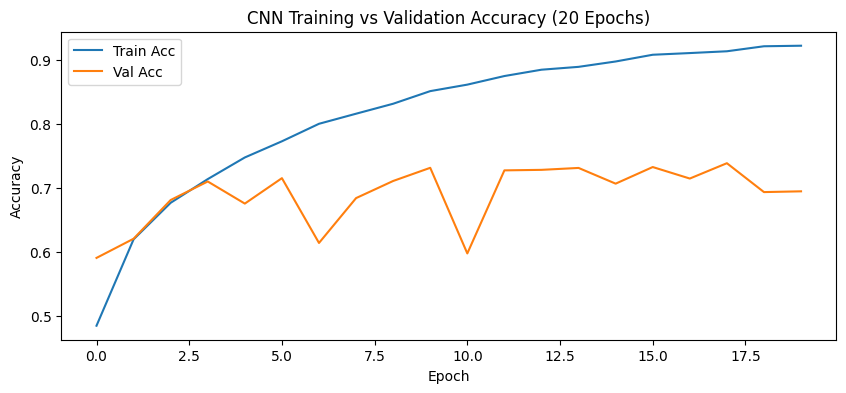

In [15]:
# Task 3: Train CNN for 20 epochs
cnn_20ep = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

cnn_20ep.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_20ep_history = cnn_20ep.fit(
    x_train_norm, y_train,
    epochs=20,
    validation_split=0.1,
    batch_size=64
)

cnn_20ep_loss, cnn_20ep_acc = cnn_20ep.evaluate(x_test_norm, y_test)
print("CNN (20 Epochs) Test Accuracy:", cnn_20ep_acc)

# Plot learning curve for 20 epochs
plt.figure(figsize=(10,4))
plt.plot(cnn_20ep_history.history['accuracy'], label='Train Acc')
plt.plot(cnn_20ep_history.history['val_accuracy'], label='Val Acc')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("CNN Training vs Validation Accuracy (20 Epochs)")
plt.legend()
plt.show()

In [16]:
# Task 4: CNN with EarlyStopping callback
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True,
    verbose=1
)

cnn_es = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

cnn_es.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_es_history = cnn_es.fit(
    x_train_norm, y_train,
    epochs=30,                  # high max, early stopping will kick in
    validation_split=0.1,
    batch_size=64,
    callbacks=[early_stop]
)

cnn_es_loss, cnn_es_acc = cnn_es.evaluate(x_test_norm, y_test)
print("CNN with EarlyStopping Test Accuracy:", cnn_es_acc)
print("Training stopped at epoch:", len(cnn_es_history.history['val_loss']))

Epoch 1/30
197/704 ━━━━━━━━━━━━━━━━━━━━ 1:04 128ms/step - accuracy: 0.2983 - loss: 1.9735

KeyboardInterrupt: 

In [17]:
# Task 5: Train the augmented CNN model (aug_cnn_model defined above)
aug_history = aug_cnn_model.fit(
    x_train_norm, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

aug_loss, aug_acc = aug_cnn_model.evaluate(x_test_norm, y_test)
print("Augmented CNN Test Accuracy:", aug_acc)

# Final comparison of all models
final_comparison = pd.DataFrame({
    "Model": ["ANN", "Deep ANN", "CNN (10 ep)", "CNN (20 ep)", "CNN + EarlyStopping", "CNN + Augmentation"],
    "Test Accuracy": [
        round(ann_test_acc, 4),
        round(ann_deep_acc, 4),
        round(cnn_test_acc, 4),
        round(cnn_20ep_acc, 4),
        round(cnn_es_acc, 4),
        round(aug_acc, 4)
    ]
})
print(final_comparison)
final_comparison

Epoch 1/10
 10/704 ━━━━━━━━━━━━━━━━━━━━ 57s 83ms/step - accuracy: 0.1102 - loss: 2.3213

KeyboardInterrupt: 

# ✅ Conclusion
- **ANN works**, but ignores image structure
- **CNN extracts spatial features**, so it performs significantly better
- **Training strategies** like dropout, batch norm, and augmentation improve results
- This project builds strong fundamentals for **computer vision interviews and deep learning projects**